In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import kruskal
from scipy.stats import shapiro
from scipy.stats import levene

Let's explore different ways to check if our data is Gaussian or not.
For this demonstration, we will use the height-weight data.

In [5]:
df_hw = pd.read_csv('../../assets/weight-height.csv')
df_hw.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


<Axes: xlabel='Height', ylabel='Count'>

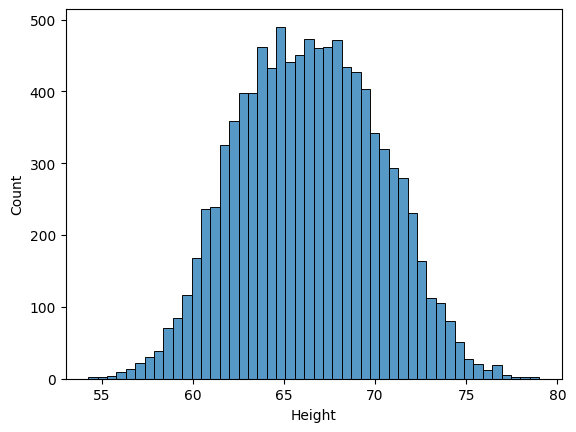

In [6]:
sns.histplot(df_hw['Height'])

1. Quantile-Quantile plot

One way to test for this is by utilizing the **QQ plot**, which stands for **Quantile-Quantile plot**.
- Think of it as a side-by-side comparison between your data and a hypothetical Gaussian (normal) distribution.


- To construct this plot, we place the quantiles (percentiles) of our data against those of a Gaussian distribution.
 - It is essentially comparing theoretical quantiles with quantiles we observe in the data.


Imagine we're looking at a scatter plot where **our data's z-scores** are compared to the **z-scores of a Gaussian distribution**.
 - **Why z-score?**: It give us a standardized way to compare different datasets.

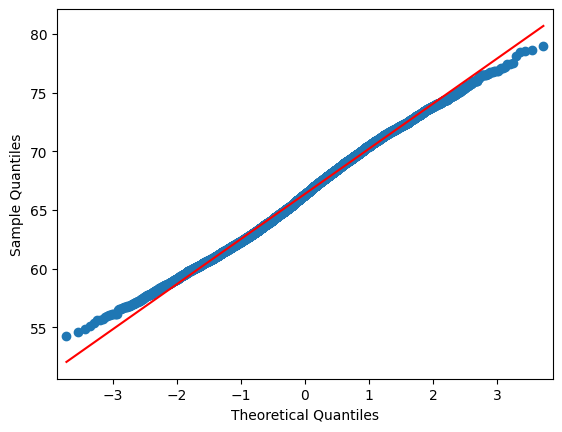

In [8]:
qqplot(df_hw['Height'], line='s')
plt.show()

In [10]:
df_wait_time = pd.read_csv('../../assets/waiting_time.csv')
df_wait_time.head()

,time
0,184.003075
1,36.721521
2,29.970417
3,75.640285
4,61.489439


<Axes: xlabel='time', ylabel='Count'>

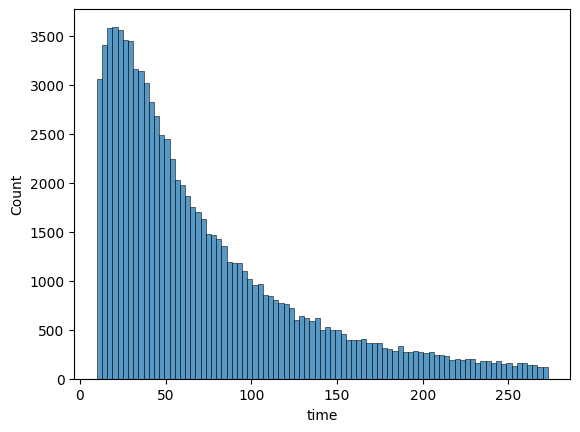

In [11]:
sns.histplot(df_wait_time['time'])

This is not a Gaussian distribution.

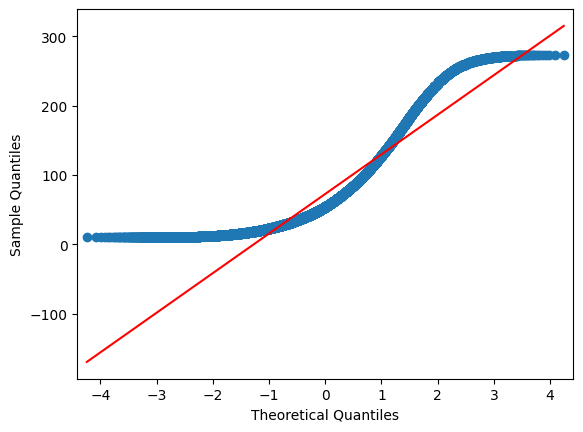

In [12]:
qqplot(df_wait_time['time'], line='s')
plt.show()

### <font color='purple'> Shapiro-Wilk test</font>
Now, let's discuss the statistical test used to assess the normality of data – the **Shapiro-Wilk test**.

This test calculates a p-value that tells you whether your data could plausibly come from a normal distribution.

Here's how it works:
- If the p-value is high (greater than, say, 0.05),
 - It suggests that the data likely does come from a normal distribution.
- Conversely, if the p-value is low (less than 0.05),
 - It indicates that the data's distribution significantly differs from a normal distribution.

In [23]:
np.random.sample(42)
height_subset = df_hw['Height'].sample(100)

H0 = "Data is Gaussian."
HA = "Data is not Gaussian."
t_stat, p_value = shapiro(height_subset)
print(f"Shapiro-Wilk statistic: {t_stat}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print(f"Reject the HO means: '{HA}'")
else:
    print(f"Fail to reject the HO means: '{H0}'")

Shapiro-Wilk statistic: 0.9872444544245522
P-value: 0.4542705406549142
Fail to reject the HO means: 'Data is Gaussian.'


Let's also verify if the QQ Plot of `waiting time data` gave us the correct inference.

In [25]:
np.random.sample(42)
df_wt_subset = df_wait_time['time'].sample(50)
t_stat, p_value = shapiro(df_wt_subset)
print(f"Shapiro-Wilk statistic: {t_stat}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print(f"Reject the HO means: '{HA}'")
else:
    print(f"Fail to reject the HO means: '{H0}'")

Shapiro-Wilk statistic: 0.870719808942608
P-value: 5.920432058660884e-05
Reject the HO means: 'Data is not Gaussian.'


## <font color='purple'> Levene Test</font>

Another assumption of ANOVA is that: `There should be equal variance in different groups/categories in our data`

Imagine you have multiple groups, and you want to see if the variability (spread) of data within each group is roughly the same.

> **How would we go about verifying that?**

We use a test known as the **Levene Test**.

<Axes: xlabel='Height', ylabel='Count'>

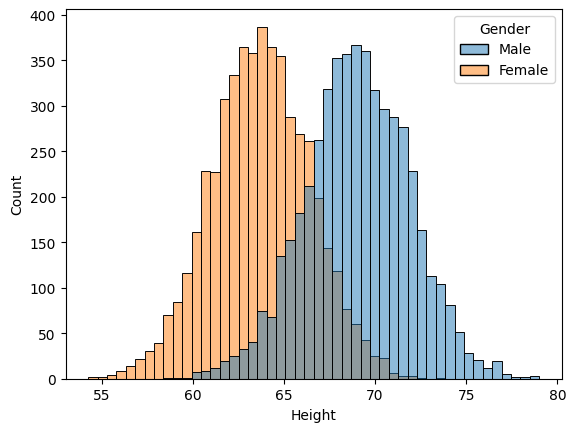

In [28]:
sns.histplot(data=df_hw, x='Height', hue='Gender')

In [32]:
height_men = df_hw[df_hw['Gender'] == 'Male']['Height']
height_women = df_hw[df_hw['Gender'] == 'Female']['Height']
print(f'men mean height: {height_men.mean()}')
print(f'women mean height: {height_women.mean()}')

t_stat, p_value = ttest_ind(height_men, height_women)
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

men mean height: 69.02634590621741
women mean height: 63.70877360342507
T-statistic: 95.60271449148823
P-value: 0.0


In [33]:
height_men.var(), height_women.var()

(np.float64(8.198843252520467), np.float64(7.2699474936701245))

To establish whether this difference we see in variance is chance or significant, we have to use Levene test

In [34]:
H0 = 'Variances are equal'
HA = 'Variances are not equal'
alpha = 0.05

t_stat, p_value = levene(height_men, height_women)
print(f"Levene's test statistic: {t_stat}") 
print(f"P-value: {p_value}")

if p_value < alpha:
    print(f"Reject the HO means: '{HA}'")
else:
    print(f"Fail to reject the HO means: '{H0}'")

Levene's test statistic: 12.284910854677701
P-value: 0.0004586349895436178
Reject the HO means: 'Variances are not equal'
